In [22]:
import os

In [23]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [24]:
class state(TypedDict):
    temp_celsius:float
    temp_fahrenheit:float
    weather_status: str

In [25]:
def convert_temp(state:state)->state:
    celsius=state['temp_celsius']
    fahrenheit=(celsius*9/5)+32
    return {
        "temp_celsius": celsius,
        "temp_fahrenheit": fahrenheit,
    }

In [31]:
def label_weather(state: state):
    f = state["temp_fahrenheit"]

    if f >= 86:
        status = "Hot"
    elif f >= 68:
        status = "Warm"
    else:
        status = "Cold"

    return {"weather_status": status}

In [32]:
graph=StateGraph(state)
graph.add_node('convert_temp',convert_temp)
graph.add_node('label_weather',label_weather)
graph.add_edge(START,'convert_temp')
graph.add_edge('convert_temp','label_weather')
graph.add_edge('label_weather',END)
workflow=graph.compile()

In [33]:
workflow.invoke({'temp_celsius': 25})

{'temp_celsius': 25, 'temp_fahrenheit': 77.0, 'weather_status': 'Warm'}

In [34]:
from IPython.display import Image

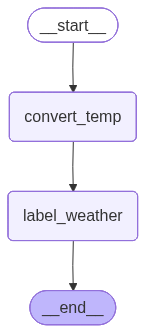

In [35]:
Image(workflow.get_graph().draw_mermaid_png())

In [37]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
llm=ChatOpenAI(model=os.getenv('MODEL_NAME'),temperature=0)

In [39]:
class state(TypedDict):
    question:str
    answer:str

In [40]:
def llm_qa(state:state)->state:
    question=state['question']
    prompt=f"Answer the following question: {question}"
    answer=llm.invoke(prompt).content
    state['answer']=answer
    return state

In [41]:
graph=StateGraph(state)
graph.add_node('llm_qa',llm_qa)
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)
workflow=graph.compile()

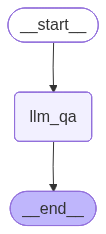

In [42]:
Image(workflow.get_graph().draw_mermaid_png())

In [43]:
workflow.invoke({'question':'Who is Clint Eastwood?'})

{'question': 'Who is Clint Eastwood?',
 'answer': 'Clint Eastwood is an American actor, film director, producer, and composer. He first rose to fame in the 1960s for his role as the "Man with No Name" in Sergio Leone\'s "Dollars Trilogy" of spaghetti westerns, including *A Fistful of Dollars*, *For a Few Dollars More*, and *The Good, the Bad and the Ugly*. He later became widely known for playing the tough cop Harry Callahan in the "Dirty Harry" film series.\n\nEastwood has also had a highly successful career as a director and producer, winning Academy Awards for Best Director and Best Picture for *Unforgiven* (1992) and *Million Dollar Baby* (2004). He is known for his distinctive style, often focusing on themes of justice, morality, and the American experience. In addition to his film career, Eastwood has been involved in politics, serving as the mayor of Carmel-by-the-Sea, California, from 1986 to 1988.'}